## Intro to Predictive Processing Ecephys NWBs
This notebook just shows how to extract the data-of-interest out of OpenScope's Predictive Process NWB files for Ecephys, which have been uploaded to the DANDI Archive.

The important information from experimental session in these files currently available are:
- Subject information
- Stimulus tables
- LFP (local field potential) traces
- Neuronal unit spike times from Kilosort4 and associated metrics
- Neuropixels probe electrodes table
- Eye tracking on screen (from deeplabcut)
- Running wheel rotation

In [1]:
%matplotlib inline
import os
import pathlib
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import polars as pl

# For benchmarking: use a new cache before importing lazynwb to ensure catalog scanning time is included
_lazynwb_demo_cache_dir = pathlib.Path(tempfile.mkdtemp(prefix="lazynwb-demo-cache-"))
os.environ["LAZYNWB_CATALOG_CACHE_PATH"] = str(_lazynwb_demo_cache_dir / "catalog.sqlite")
import lazynwb

# Set polars options for better notebook display
pl.Config.set_fmt_str_lengths(10_000).set_tbl_width_chars(-1)

# We're accessing a public dataset, so we can use anonymous access (credentials not required):
lazynwb.config.anon = True

t0 = time.perf_counter()

The NWB files can be found in Dandiset 001424 on DANDI [here](https://dandiarchive.org/dandiset/001637?pos=1). The NWB can be downloaded with the DANDI client and then opened with `pynwb` - but here we will use `lazynwb` to open the NWB file directly from S3 and extract the data of interest.

In [2]:
%%time
dandiset_id = "001637"
dandi_filepath = "sub-820459/sub-820459_ses-ecephys-820459-2025-11-12-14-34-33_ecephys.nwb"

s3_source = lazynwb.get_dandi_sources(dandiset_id, version="draft", asset_filter=lambda asset: dandi_filepath in asset["path"])[0]

CPU times: total: 1.45 s
Wall time: 1.89 s


### Open NWB File
`lazynwb` has both a functional and an object-oriented API. 

To get an overview of the structure of a single NWB file, we can load the analog of the `pynwb.NWBFile` object:

In [3]:
%%time
nwb = lazynwb.LazyNWB(s3_source)

CPU times: total: 0 ns
Wall time: 4.03 ms


Creating the object for the file is lazy, but displaying the HTML representation triggers fetching metadata and the full tree of internal container paths:

In [ ]:
%%time
display(nwb)        # without display() the %%time reported is incorrect

LazyNWB(HTTPPath('https://dandiarchive.s3.amazonaws.com/blobs/4b3/2a4/4b32a46d-f4de-467e-8cc8-ab354bef17cf', protocol='https'))

CPU times: total: 62.5 ms
Wall time: 66.2 ms


### Stimulus
Alternatively, one can access everything via the functional API, passing the s3 source and internal paths:

In [6]:
INTERNAL_PATHS = lazynwb.get_internal_paths(s3_source, include_metadata=True)

for p in INTERNAL_PATHS:
    if p.startswith("/intervals/"):
        print(p)

/intervals/40 hz pulse train_presentations
/intervals/5 hz pulse train_presentations
/intervals/Control block 1_presentations
/intervals/Control block 2_presentations
/intervals/Control block 3_presentations
/intervals/Control block 4_presentations
/intervals/RF mapping_presentations
/intervals/Sequence mismatch block_presentations
/intervals/Trippy_presentations
/intervals/Zebra_presentations
/intervals/raised_cosine_presentations
/intervals/spontaneous_presentations


`get_df()` has fuzzy matching for internal paths, so you can pass the exact internal path or just a partial name but beware that there may be multiple matches!

In [6]:
%%time
stim_table = nwb.get_df("Sequence mismatch block_presentations")
stim_table

CPU times: total: 625 ms
Wall time: 4.73 s


,BlockLabel,BlockNumber,BlockType,Delay,DiameterX,DiameterY,Duration,Orientation,SequenceNumber,SpatialFrequency,...,phase,start_time,stim_block,stim_index,stim_name,stim_type,stop_time,_nwb_path,_table_path,_table_index
0,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,1.5707963267948966,1.0,0.04,...,0.0,435.529126,1.0,1.0,Sequence mismatch block,None or Blank,435.796017,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,0
1,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,0.7853981633974483,1.0,0.04,...,0.0,435.796017,1.0,1.0,Sequence mismatch block,None or Blank,436.062908,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,1
2,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,0.0,1.0,0.04,...,0.0,436.062908,1.0,1.0,Sequence mismatch block,None or Blank,436.329799,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,2
3,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,0.7853981633974483,1.0,0.04,...,0.0,436.329799,1.0,1.0,Sequence mismatch block,None or Blank,436.596691,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,3
4,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,0.0,1.0,0.04,...,0.0,436.596691,1.0,1.0,Sequence mismatch block,None or Blank,436.863584,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6235,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,1.5707963267948966,1248.0,0.04,...,0.0,2097.027287,1.0,1.0,Sequence mismatch block,None or Blank,2097.294176,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,6235
6236,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,0.7853981633974483,1248.0,0.04,...,0.0,2097.294176,1.0,1.0,Sequence mismatch block,None or Blank,2097.561064,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,6236
6237,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,0.0,1248.0,0.04,...,0.0,2097.561064,1.0,1.0,Sequence mismatch block,None or Blank,2097.827954,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,6237
6238,Sequence mismatch block,2.0,sequential_oddball,0.0,360.0,360.0,0.25,0.7853981633974483,1248.0,0.04,...,0.0,2097.827954,1.0,1.0,Sequence mismatch block,None or Blank,2098.094849,https://dandiarchive.s3.amazonaws.com/blobs/4b...,intervals/Sequence mismatch block_presentations,6238


In [7]:
np.unique(stim_table["TrialType"])

array(['halt', 'omission', 'orientation_45', 'orientation_90',
       'sequence_omission', 'standard'], dtype=object)

### LFP

In [8]:
for p in INTERNAL_PATHS:
    if "LFP" in p:
        print(p)

/processing/ecephys/LFP/ElectricalSeriesProbeA-LFP
/processing/ecephys/LFP/ElectricalSeriesProbeA-LFP/electrodes
/processing/ecephys/LFP/ElectricalSeriesProbeB-LFP
/processing/ecephys/LFP/ElectricalSeriesProbeB-LFP/electrodes
/processing/ecephys/LFP/ElectricalSeriesProbeC-LFP
/processing/ecephys/LFP/ElectricalSeriesProbeC-LFP/electrodes
/processing/ecephys/LFP/ElectricalSeriesProbeD-LFP
/processing/ecephys/LFP/ElectricalSeriesProbeD-LFP/electrodes
/processing/ecephys/LFP/ElectricalSeriesProbeF-LFP
/processing/ecephys/LFP/ElectricalSeriesProbeF-LFP/electrodes


Conversion to `np.array` eagerly loads the data, which is a bad idea when streaming remote files - where possible, slice the data to read lazily instead:


(6767034,)
(6767034, 96)


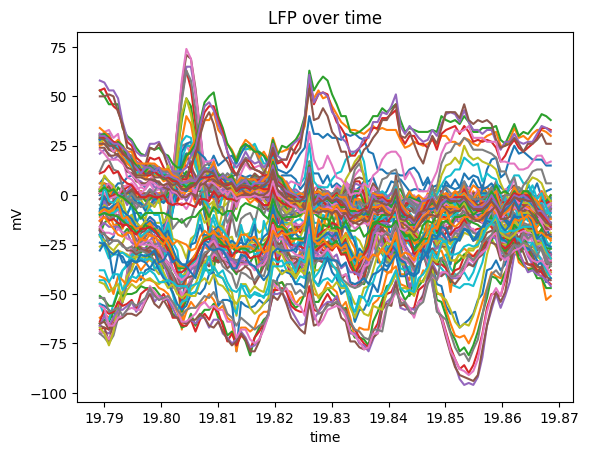

CPU times: total: 422 ms
Wall time: 833 ms


In [9]:
%%time
lfp = nwb.get_timeseries("ProbeC-LFP")

print(lfp.timestamps.shape)
print(lfp.data.shape)


plt.plot(lfp.timestamps[:100], lfp.data[:100])
plt.xlabel("time")
plt.ylabel("mV")
plt.title("LFP over time")
plt.show()

### Spike Sorted Units and Metrics
The units table can be very large, with a mix of data scales: aside fraom scalar metrics columns, it contains list columns (spike times) and array columns (waveforms). When reading remote data, we want to extract only the rows and columns we need, and avoid materializing the entire table.

To do this, we use the concept of a `polars.LazyFrame`. 

In [ ]:
%%time
units_lf = lazynwb.scan_nwb(s3_source, 'units')
display(units_lf)

CPU times: total: 188 ms
Wall time: 202 ms


CPU times: total: 93.8 ms
Wall time: 174 ms


Nothing on a `LazyFrame` is computed until we call `collect()`, which triggers the computation and materializes a `DataFrame`. This allows us to do all of our slicing and dicing with lazy expressions, and only fetch the data we need when we call `collect()`.

In [11]:
%%time
units_lf.collect_schema()

CPU times: total: 0 ns
Wall time: 1 ms


Schema([('amplitude', Float64),
        ('amplitude_cutoff', Float64),
        ('amplitude_cv_median', Float64),
        ('amplitude_cv_range', Float64),
        ('amplitude_median', Float64),
        ('d_prime', Float64),
        ('decoder_label', String),
        ('decoder_probability', Float64),
        ('default_qc', Boolean),
        ('depth', Float64),
        ('device_name', String),
        ('drift_mad', Float64),
        ('drift_ptp', Float64),
        ('drift_std', Float64),
        ('electrodes', List(Int64)),
        ('estimated_x', Float64),
        ('estimated_y', Float64),
        ('estimated_z', Float64),
        ('exp_decay', Float64),
        ('extremum_channel_index', Int64),
        ('firing_range', Float64),
        ('firing_rate', Float64),
        ('half_width', Float64),
        ('id', Int64),
        ('isi_violations_count', Int64),
        ('isi_violations_ratio', Float64),
        ('isolation_distance', Float64),
        ('ks_unit_id', Int64),
        ('l_rat

To materialze a subset of columns, use `.select()`, then call `collect()`: 

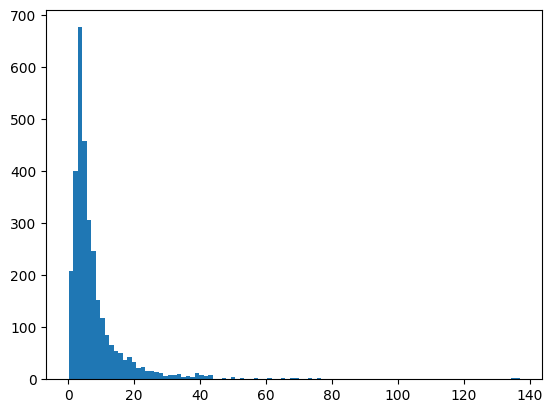

In [12]:
plt.hist(units_lf.select("snr").collect()["snr"], bins=100)
plt.show()

To work with the units table: filter rows based on scalar metrics and metadata (unit quality, brain area), then select the data columns you need (e.g. spike times, waveforms):

In [13]:
selected_units_lf = (
    units_lf
    .filter(
        "default_qc",                   # keep rows where this boolean col is True (indicates whether the unit passed default quality control criteria)
        pl.col("snr") > 10,        # AND only rows where the signal-to-noise ratio is greater than 10
                                        # filters can also be combined with & and |
    )
    .select("unit_name", "spike_times") # after applying the row filters above, only return these columns
)
selected_units_lf

At first, this updated `LazyFrame` just contains the schema information and the query plan.

When we call `.collect()`, the query is executed and we get back a `DataFrame` with actual data:

In [14]:
%%time
selected_units = selected_units_lf.collect()
selected_units

CPU times: total: 844 ms
Wall time: 4.94 s


ComputeError: caught exception during execution of a Python source, exception: KeyboardInterrupt: 

To convert to a `pandas` dataframe, just call `.to_pandas()` on the `polars` dataframe. Note that list columns are handled as `object` dtype in pandas, so you may need to convert them to `numpy` arrays for easier handling.

In [ ]:
# conversion to np.array required for plotting
unit0 = selected_units.to_dicts()[0]
plt.eventplot(unit0["spike_times"][:100], lw=0.5)
plt.title(f"Unit {unit0['unit_name']} spike times", fontsize=10)
plt.xlabel("Time (s)")
plt.yticks([])
plt.show()

### Electrodes and Unit Brain Location
As of writing this, we *do not* have CCF locations packaged with our NWBs for this project, but for future NWB's the electrodes table will contain the location in the brain of each electrode. This table will be usable to get the location for each unit using the function `get_unit_location` below, which will include both the labeled brain region and the x,y,z coordinates.

In [ ]:
for p in INTERNAL_PATHS:
    if "general" in p:
        print(p)

### Eye Tracking

In [ ]:
for p in INTERNAL_PATHS:
    if "eye_tracking" in p:
        print(p)

In [ ]:
%%time
pupil_tracking = nwb.get_df('/processing/eye_tracking/pupil')
pupil_tracking

In [ ]:
xs = pupil_tracking['data_x']
ys = pupil_tracking['data_y']
start, end = 20, 5000

# generate colors along viridis for the range
colors = mpl.cm.viridis(np.linspace(0, 1, end-start))

# plot the line
plt.plot(xs[start:end], ys[start:end], zorder=0, linewidth=0.25, color='gray')

# scatter with colormap
sc = plt.scatter(xs[start:end], ys[start:end], s=5, c=colors, zorder=1)

plt.xlabel("Relative X position")
plt.ylabel("Relative Y position")

# colorbar for the gradient
cbar = plt.colorbar(sc)
cbar.ax.get_yaxis().labelpad = 15
cbar.ax.set_ylabel('Time', rotation=270)
cbar.set_ticks([])

plt.show()

### Running Wheel

In [ ]:
for p in INTERNAL_PATHS:
    if "running_wheel" in p:
        print(p)

In [ ]:
%%time
wheel_rotation = nwb.get_df('/acquisition/raw_running_wheel_rotation')
wheel_times = wheel_rotation.timestamps
wheel_trace = wheel_rotation.data

print(wheel_times.shape)
print(wheel_trace.shape)

In [ ]:
plt.plot(wheel_times, wheel_trace)
plt.title("Wheel Rotation over Time")
plt.xlabel("Time")
plt.show()

In [ ]:
plt.plot(wheel_times, np.cumsum(wheel_trace))

---
## Benchmark
Time elapsed (s):

In [ ]:
time.perf_counter() - t0

---
## Bonus: Multi-file access
One of the main features of `lazynwb` is the ability to access a concatenated table across any NWB files.

Let's fetch all the ecephys files in the same dandiset:

In [ ]:
%%time
s3_sources: list[str] = lazynwb.get_dandi_sources(dandiset_id, version="draft", asset_filter=lambda asset: "ecephys" in asset["path"])
print(len(s3_sources))

We can then construct a `LazyFrame` across all units in all files. 

By default, `lazynwb` scans every file's units table schema individually and finds the common super-schema. If you know that every schema is the same, you can add the option `infer_schema_length=1` to just scan the first file.

In [ ]:
%%time
units_lf = lazynwb.scan_nwb(s3_sources, 'units')

The `_nwb_path` column is added to indicate the source file for each unit, and `_table_index` is a row's original index in its source file.  

As with a single source, we use filter pushdown and column projection to limit the data read to only the bare minimum:

In [ ]:
%%time
(
    units_lf
    .select("default_qc", "_nwb_path", "_table_index")
    .group_by("_nwb_path")
    .agg(
        pl.col("_table_index").len().alias("n_units"),
        pl.col("default_qc").sum().truediv(pl.col("default_qc").count()).alias("proportion_good_units"),
    )
    .sort("n_units")
    .collect()
)